In [1]:
import os
import re
import pandas as pd
import plotnine as pln
from statsmodels.formula.api import ols

In [2]:
def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation)
    if parts:
        wt, site, mut = parts.groups()
        return [wt, int(site), mut]
    else:
        return [None, None, None]
    
split_mut_sit('H2T')

['H', 2, 'T']

# Relative variability of site means

In [6]:
res_dict = {'source':[], 'Dataset':[], 'RVSM':[]}

for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
        if file not in ['PABP_YEAST_Fields2013_doubles.csv', 'parEparD_Laub2015_all.csv', 'AAV2_CAPSD_Sinai.csv', 'PESV_POLG_Tsuboyama.csv', 'BP434_RPC1_Tsuboyama.csv']:
            data = pd.read_csv(f'../data/{source}/metadata/{file}')
            data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
            
            # equation
            total_std = data['target'].std()
            grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].mean()
            sd_sites = grouped_data['target'].std()
            variance = sd_sites / total_std


            res_dict['source'].append(source)
            res_dict['Dataset'].append(file.replace('.csv', ''))
            res_dict['RVSM'].append(variance)

RVSM = pd.DataFrame.from_dict(res_dict)
RVSM['source'] = pd.Categorical(RVSM['source'], categories=['viral', 'cellular'])
RVSM

,source,Dataset,RVSM
0,cellular,TIM_THETH,0.707607
1,cellular,TIM_THEMA,0.667472
2,cellular,MK01_HUMAN_Johannessen,0.501967
3,cellular,IF1_ECOLI,0.716184
4,cellular,TIM_SULSO,0.679531
...,...,...,...
69,viral,CVB3_2A_Alvarez,0.776574
70,viral,CVB3_3A_Alvarez,0.648906
71,viral,SARS2_PLPRO_activity_Wu,0.817721
72,viral,SARS2_BA1_SPIKE_Dadonaite,0.682066


In [7]:
RVSM_dict = {}
for idx, col in RVSM.iterrows():
    RVSM_dict[col['Dataset']] = col['RVSM']

# fraction SD

In [8]:
cutoff = 0.7
res_dict = {'source':[], 'Dataset':[], 'fraction':[]}

for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
        data = pd.read_csv(f'../data/{source}/metadata/{file}')
        data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
        
        grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].std()
        
        global_std = data['target'].std()
        grouped_data['frac_std'] = grouped_data['target'] / global_std
        sites = list(grouped_data.query(f'frac_std > {cutoff}')['site'].values)
        data = data.query('site in @sites')
        fraction = len(sites)/grouped_data.shape[0] # frac=part/total

        res_dict['source'].append(source)
        res_dict['Dataset'].append(file.replace('.csv', ''))
        res_dict['fraction'].append(fraction)

frac_SD = pd.DataFrame.from_dict(res_dict)
frac_SD['source'] = pd.Categorical(frac_SD['source'], categories=['viral', 'cellular'])
frac_SD

,source,Dataset,fraction
0,cellular,TIM_THETH,0.475000
1,cellular,TIM_THEMA,0.425000
2,cellular,MK01_HUMAN_Johannessen,0.777159
3,cellular,IF1_ECOLI,0.305556
4,cellular,TIM_SULSO,0.537500
...,...,...,...
74,viral,CVB3_2A_Alvarez,0.366667
75,viral,CVB3_3A_Alvarez,0.674157
76,viral,SARS2_PLPRO_activity_Wu,0.295238
77,viral,SARS2_BA1_SPIKE_Dadonaite,0.582066


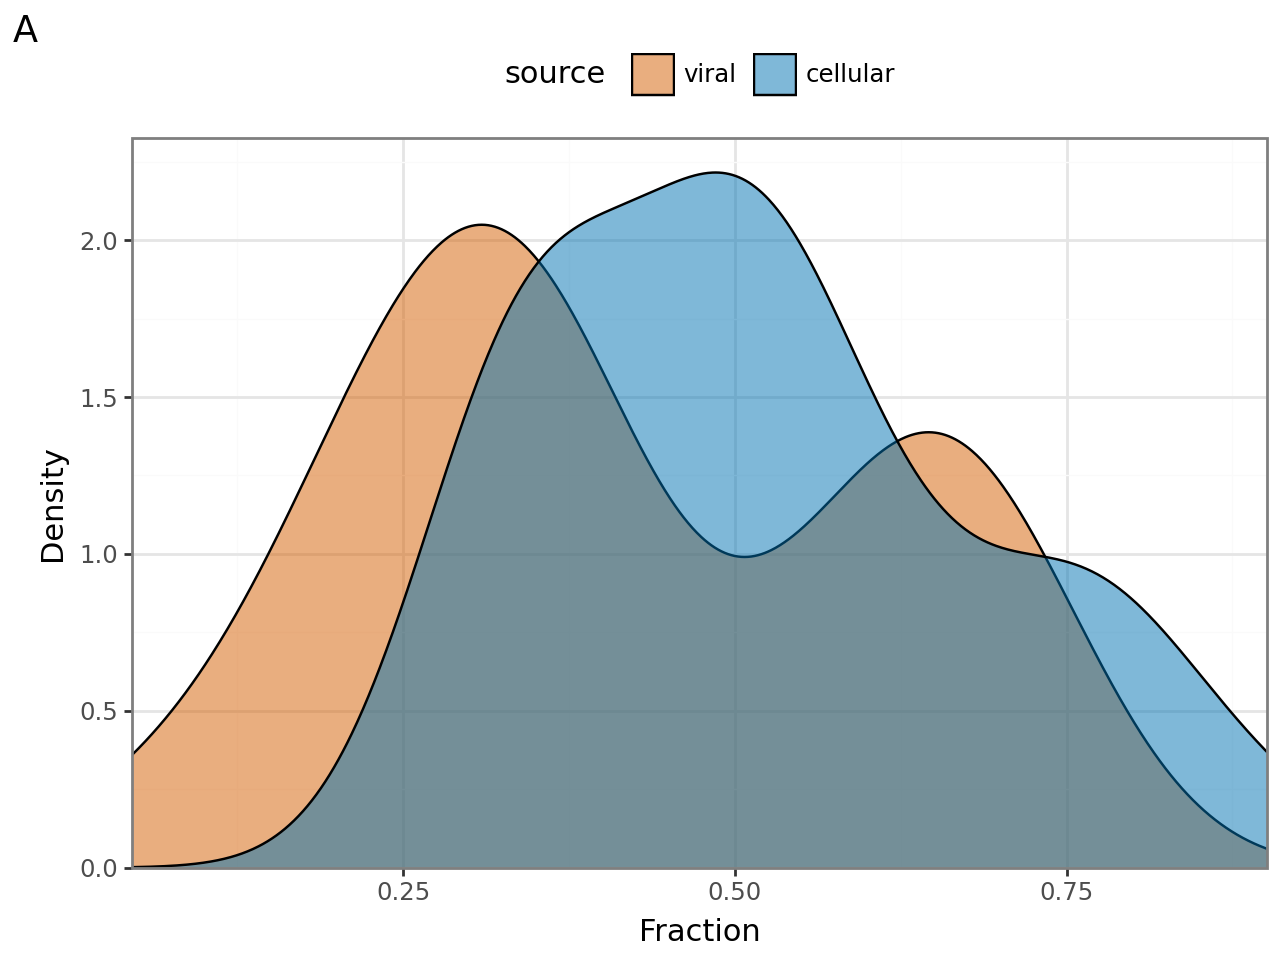

In [9]:
(
    pln.ggplot(frac_SD, pln.aes(x='fraction', fill='source'))
    +pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Fraction',
        y='Density',
        tag='A')
    + pln.theme(
        #figure_size=(3.5,3), 
        legend_position='top')
    )

In [10]:
frac_SD_dict = {}
for idx, col in frac_SD.iterrows():
    frac_SD_dict[col['Dataset']] = col['fraction']


# fraction SD ranked

In [11]:
cutoff = 0.7
res_dict = {'source':[], 'Dataset':[], 'fraction':[]}

for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
        data = pd.read_csv(f'../data/{source}/metadata/{file}')
        data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))

        data = data.sort_values('target')
        data['rank'] = [x for x in range(len(data))]
        
        global_std = data['rank'].std()
        grouped_data = data.groupby(['site'], as_index=False, observed=True)['rank'].std()
        
        grouped_data['frac_std'] = grouped_data['rank'] / global_std
        sites = list(grouped_data.query(f'frac_std > {cutoff}')['site'].values)
        data = data.query('site in @sites')
        fraction = len(sites)/grouped_data.shape[0] # frac=part/total

        res_dict['source'].append(source)
        res_dict['Dataset'].append(file.replace('.csv', ''))
        res_dict['fraction'].append(fraction)

frac_SD_ranked = pd.DataFrame.from_dict(res_dict)
frac_SD_ranked['source'] = pd.Categorical(frac_SD_ranked['source'], categories=['viral', 'cellular'])
frac_SD_ranked

,source,Dataset,fraction
0,cellular,TIM_THETH,0.425000
1,cellular,TIM_THEMA,0.462500
2,cellular,MK01_HUMAN_Johannessen,0.752089
3,cellular,IF1_ECOLI,0.361111
4,cellular,TIM_SULSO,0.525000
...,...,...,...
74,viral,CVB3_2A_Alvarez,0.473333
75,viral,CVB3_3A_Alvarez,0.528090
76,viral,SARS2_PLPRO_activity_Wu,0.282540
77,viral,SARS2_BA1_SPIKE_Dadonaite,0.679744


In [12]:
frac_SD_ranked_dict = {}
for idx, col in frac_SD_ranked.iterrows():
    frac_SD_ranked_dict[col['Dataset']] = col['fraction']


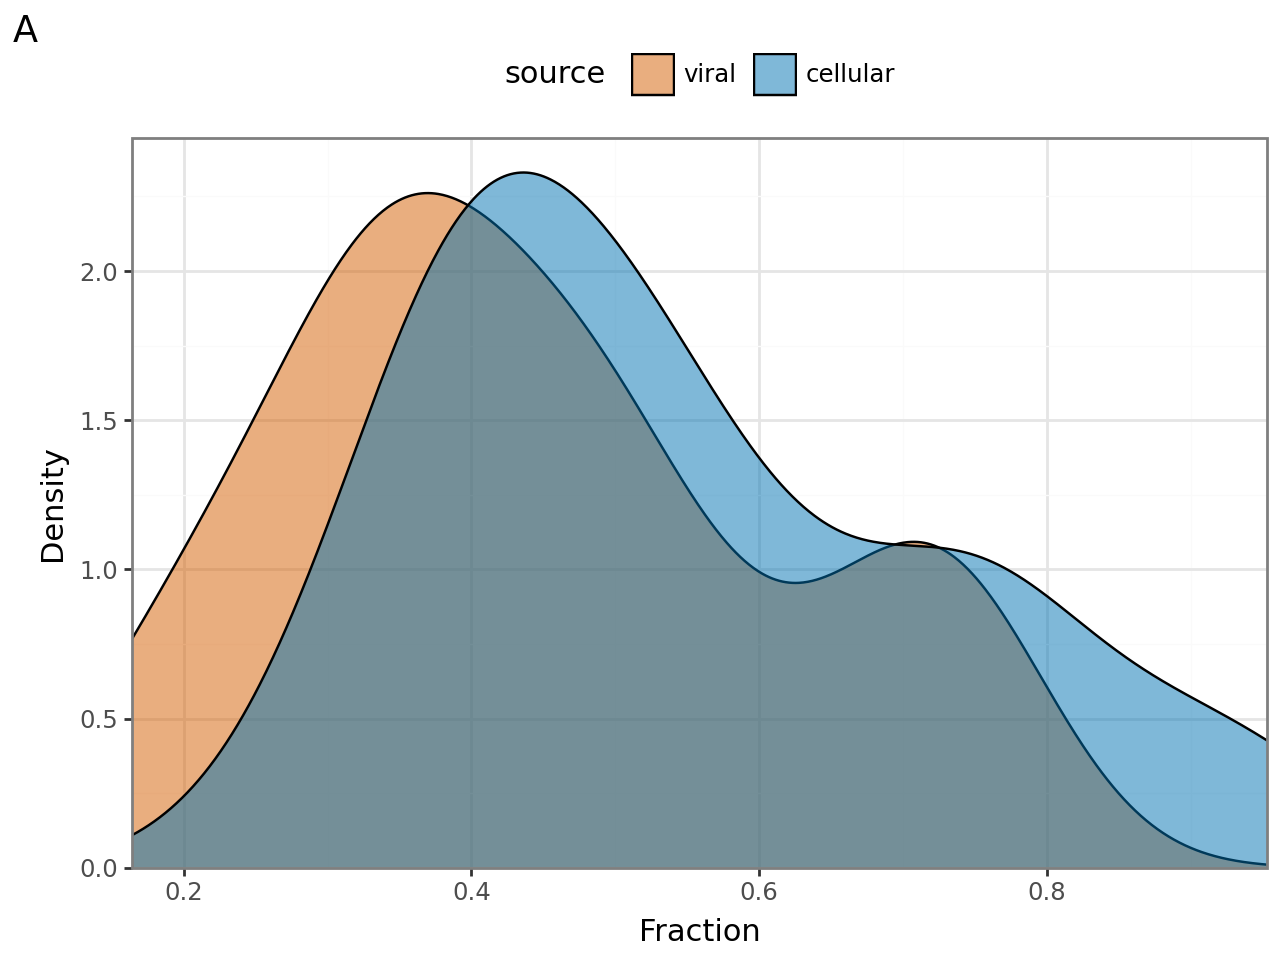

In [13]:
(
    pln.ggplot(frac_SD_ranked, pln.aes(x='fraction', fill='source'))
    +pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Fraction',
        y='Density',
        tag='A')
    + pln.theme(
        #figure_size=(3.5,3), 
        legend_position='top')
    )

# Coverage

In [14]:
# load viral metadata and calculate coverage
multiples = ['PESV_POLG_Tsuboyama', 'BP434_RPC1_Tsuboyama', 'AAV2_CAPSD_Sinai', 'parEparD_Laub2015_all', 'PABP_YEAST_Fields2013_doubles']

coverage = []
dataset = []
sources = []


for source in ['cellular', 'viral']:
    mtda_dir = f"../data/{source}/metadata" 
    for file in os.listdir(mtda_dir):
        filename = file.removesuffix('.csv')
        if filename not in multiples:
            mtda = pd.read_csv(os.path.join(mtda_dir, file))
            mtda = mtda.query("mutant != 'WT'")
            mtda["site"] = [int(s[1:-1]) for s in mtda["mutant"]]
            sites_cov = {}
            # find number of mutations in each site
            for site in mtda["site"]:
                if site in sites_cov:
                    sites_cov[site] += 1
                else:
                    sites_cov[site] = 1
            # use number of mutations to calculate coverage value by site
            for site in sites_cov:
                sites_cov[site] = sites_cov[site]/20
            # calculate sum of mutation coverages
            sum_cov = 0
            for site in sites_cov:
                sum_cov += sites_cov[site]
            # calculate coverage
            seq_len = len(mtda["sequence"][0])
            cov = sum_cov/seq_len
            
            coverage.append(cov)
            dataset.append(filename)
            sources.append(source)


cov = pd.DataFrame({"Dataset": dataset, "Coverage": coverage, "Source":sources})
cov['Source'] = pd.Categorical(cov['Source'], categories=['viral', 'cellular'])
cov

,Dataset,Coverage,Source
0,TIM_THETH,0.299016,cellular
1,TIM_THEMA,0.301389,cellular
2,MK01_HUMAN_Johannessen,0.945694,cellular
3,IF1_ECOLI,0.999306,cellular
4,TIM_SULSO,0.306250,cellular
...,...,...,...
69,CVB3_2A_Alvarez,0.997333,viral
70,CVB3_3A_Alvarez,0.994382,viral
71,SARS2_PLPRO_activity_Wu,0.844146,viral
72,SARS2_BA1_SPIKE_Dadonaite,0.432266,viral


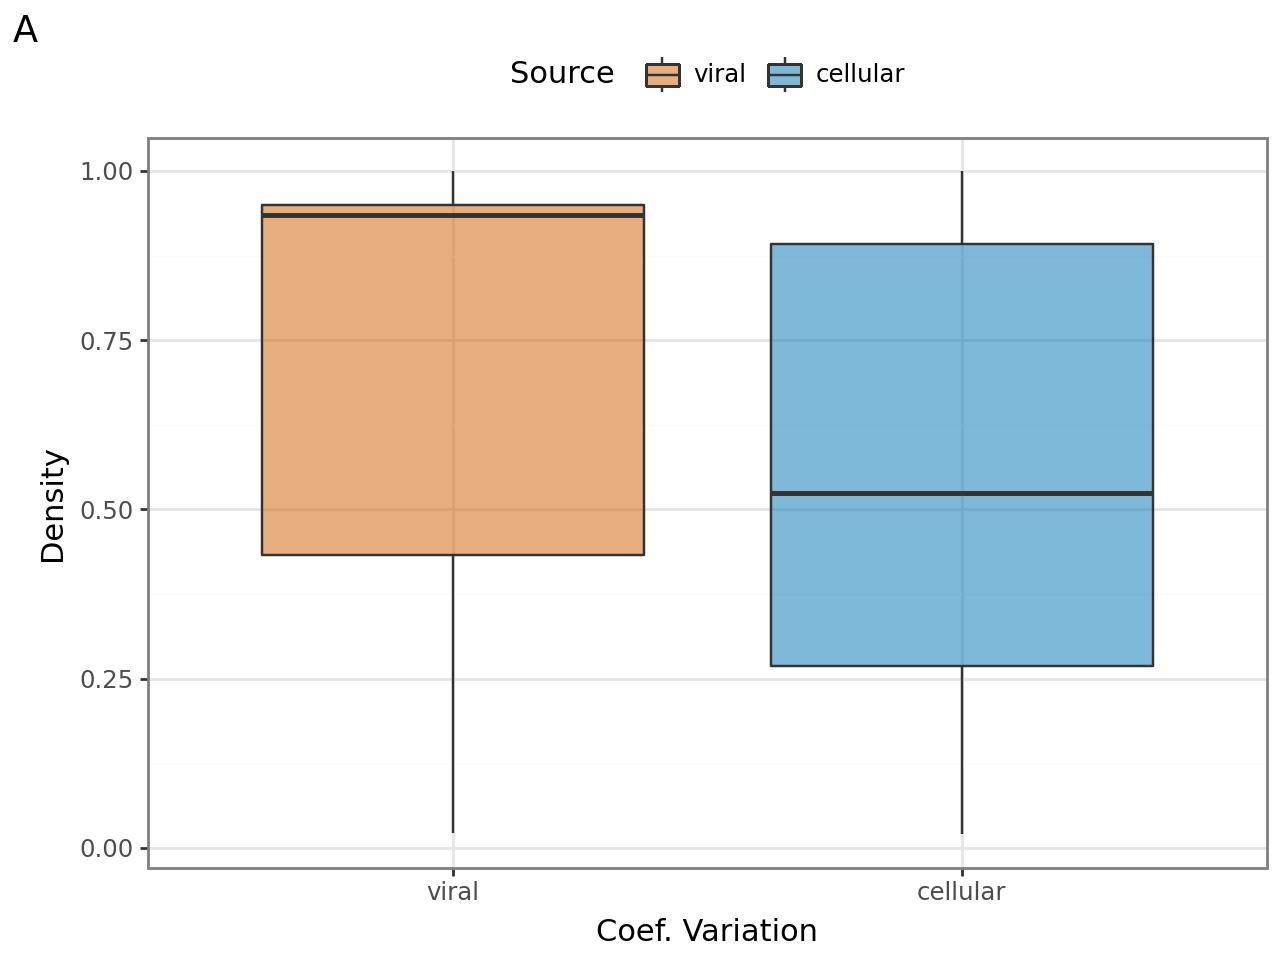

In [15]:
(
    pln.ggplot(cov, pln.aes(x='Source', y='Coverage', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_boxplot(alpha=0.5)
    + pln.theme_bw()
    + pln.labs(
        x='Coef. Variation',
        y='Density',
        tag='A')
    + pln.theme(
        legend_position='top')
    )

In [16]:
cov_dict = {}
for idx, col in cov.iterrows():
    cov_dict[col['Dataset']] = col['Coverage']

# Coeficient of Variation
This tells you how large the variation is relative to the overall mean value.

In [17]:
cv_df = pd.DataFrame()

for source in ['viral', 'cellular']:
    res_dir = f'../data/{source}/metadata/'
    for file in os.listdir(res_dir):
        if file not in ['PABP_YEAST_Fields2013_doubles.csv', 'parEparD_Laub2015_all.csv', 'AAV2_CAPSD_Sinai.csv', 'PESV_POLG_Tsuboyama.csv', 'BP434_RPC1_Tsuboyama.csv']:
            res_file = os.path.join(res_dir, file)
            res = pd.read_csv(res_file)
            
            res[['wt', 'site', 'mut']] = res['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))

            global_mean = res['target'].mean()
            grouped_data = res.groupby(['site'], as_index=False, observed=True)['target'].std()
            grouped_data['cv'] = grouped_data['target'] / abs(global_mean)
            grouped_data['Dataset'] = file.split('.csv')[0]
            
            cv = grouped_data.groupby(['Dataset'], as_index=False)['cv'].mean()
            cv['source'] = source
            
            cv_df = pd.concat([cv_df, cv])
        
cv_df 

,Dataset,cv,source
0,HIV1_HV1B9_ENV_DuenasDecamp,0.353339,viral
0,BPP22_COAT_Tsuboyama,0.891919,viral
0,IAV_RDRP_Li,0.360815,viral
0,EV_CAPSD_Bakhache,0.633236,viral
0,CVB3_2B_Alvarez,0.507024,viral
...,...,...,...
0,B3VI55_LIPST_Whitehead2015,0.542289,cellular
0,B3VI55_LIPSTSTABLE,0.626518,cellular
0,RL401_YEAST_Bolon2013,0.910122,cellular
0,RL401_YEAST_Bolon2014,0.304906,cellular


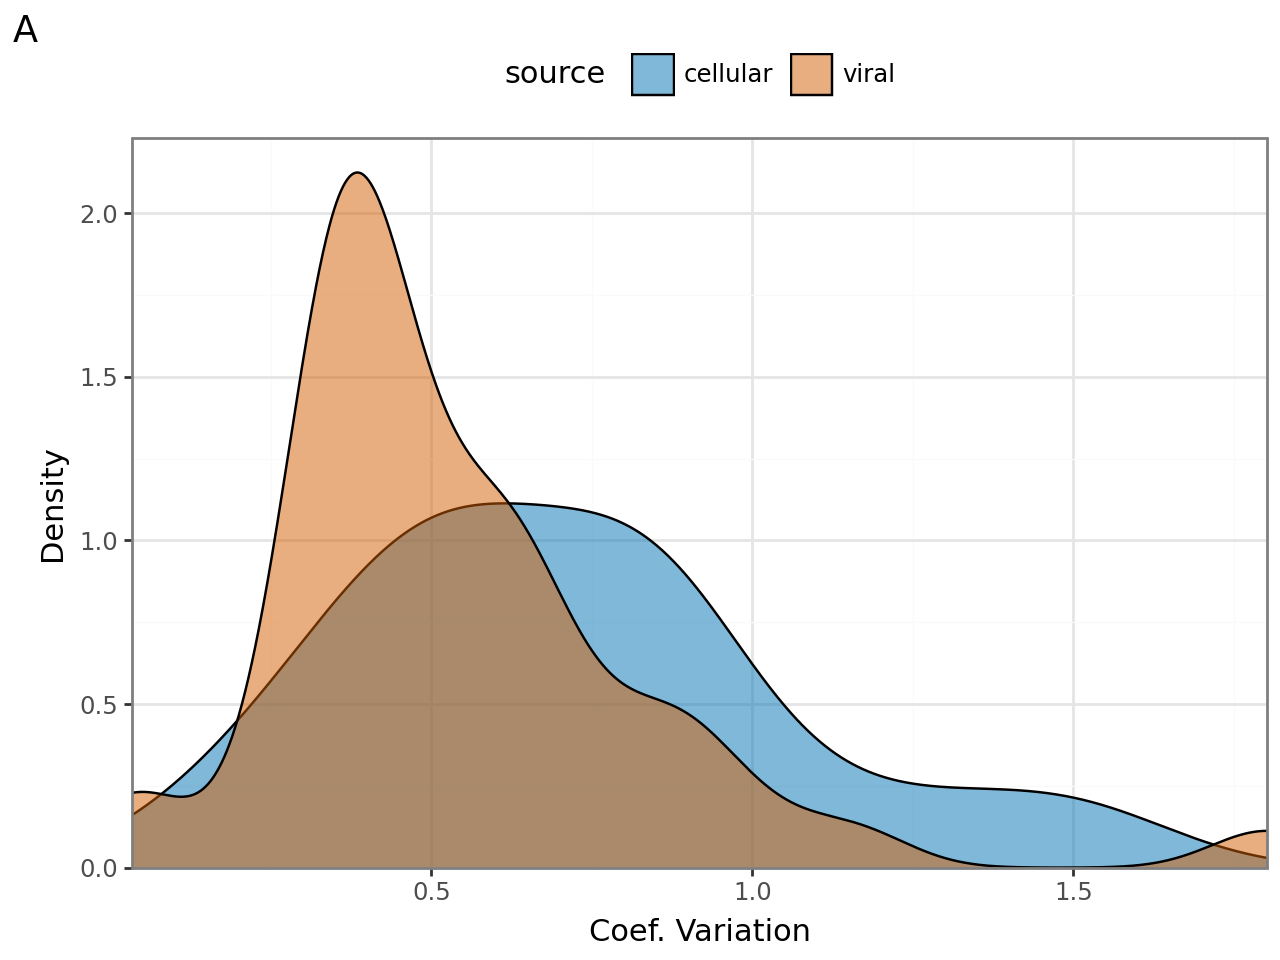

In [18]:
(
    pln.ggplot(cv_df, pln.aes(x='cv', fill='source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Coef. Variation',
        y='Density',
        tag='A')
    + pln.theme(
        legend_position='top')
    )

In [19]:
cv_dict = {}
for idx, col in cv_df.iterrows():
    cv_dict[col['Dataset']] = col['cv']


# protein length

In [20]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())


## Lasso res

In [21]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [22]:
lassocv = pd.DataFrame()
#for model in ['esm2_650m', 'esmc_600m', 'rsawhney_esm2_3B', 'esm2_viral_650m_MP15_partial_CRVDBv30', 'esm2_viral_650m_MP15_partial_URVDBv30']:
for model in ['esm2_650m']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            
            lassocv = pd.concat([lassocv, res], ignore_index=True)

rename_map = {
    'esm2_650m':'ESM-2 650M',
    'esmc_600m':'ESM C 600M',
    'esm2_viral_650m_MP15_partial_CRVDBv30':'ESM-2-CRVDB', 
    'esm2_viral_650m_MP15_partial_URVDBv30':'ESM-2-URVDB', 
    'rsawhney_esm2_3B':'ESM-2 3B Sawhney',
    'pool_split':'Pooled Split',
    'site_split':'Site Split',
    }

lassocv.replace(rename_map, inplace=True)
lassocv = lassocv.groupby(['Model', 'Source', 'Split', 'Dataset'], as_index=False)['R2_score_test'].mean()
lassocv

,Model,Source,Split,Dataset,R2_score_test
0,ESM-2 650M,cellular,Pooled Split,AMIE_PSEAE_Whitehead,0.477524
1,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPSTSTABLE,0.451530
2,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPST_Whitehead2015,0.245162
3,ESM-2 650M,cellular,Pooled Split,BG_STRSQ_hmmerbit,0.412022
4,ESM-2 650M,cellular,Pooled Split,BLAT_ECOLX_Ostermeier2014,0.653254
...,...,...,...,...,...
143,ESM-2 650M,viral,Site Split,SARS2_PLPRO_activity_Wu,0.186840
144,ESM-2 650M,viral,Site Split,SARS2_PRD0038_RBD_Starr,0.101164
145,ESM-2 650M,viral,Site Split,SARS2_RBD_binding_Starr,0.087571
146,ESM-2 650M,viral,Site Split,SARS2_RBD_expression_Starr,0.110487


# combine results

In [23]:
lassocv['cv'] = lassocv['Dataset'].map(cv_dict)
lassocv['RVSM'] = lassocv['Dataset'].map(RVSM_dict)
lassocv['coverage'] = lassocv['Dataset'].map(cov_dict)
lassocv['prot_length'] = lassocv['Dataset'].map(prot_lengths)
lassocv['fractionSD'] = lassocv['Dataset'].map(frac_SD_dict)
lassocv['fractionSD_ranked'] = lassocv['Dataset'].map(frac_SD_ranked_dict)

lassocv['Source'] = pd.Categorical(lassocv['Source'], categories=['viral', 'cellular'])

lassocv

,Model,Source,Split,Dataset,R2_score_test,cv,RVSM,coverage,prot_length,fractionSD,fractionSD_ranked
0,ESM-2 650M,cellular,Pooled Split,AMIE_PSEAE_Whitehead,0.477524,0.895529,0.684369,0.949133,346,0.504399,0.489736
1,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPSTSTABLE,0.451530,0.626518,0.596003,0.948633,439,0.660592,0.751708
2,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPST_Whitehead2015,0.245162,0.542289,0.513957,0.918793,439,0.749431,0.890661
3,ESM-2 650M,cellular,Pooled Split,BG_STRSQ_hmmerbit,0.412022,0.837254,0.600783,0.349301,501,0.526946,0.728543
4,ESM-2 650M,cellular,Pooled Split,BLAT_ECOLX_Ostermeier2014,0.653254,0.551118,0.745130,0.955944,286,0.412587,0.391608
...,...,...,...,...,...,...,...,...,...,...,...
143,ESM-2 650M,viral,Site Split,SARS2_PLPRO_activity_Wu,0.186840,0.341990,0.817721,0.844146,316,0.295238,0.282540
144,ESM-2 650M,viral,Site Split,SARS2_PRD0038_RBD_Starr,0.101164,0.878247,0.806632,0.999500,200,0.300000,0.495000
145,ESM-2 650M,viral,Site Split,SARS2_RBD_binding_Starr,0.087571,0.605886,0.828026,0.149332,1273,0.263682,0.164179
146,ESM-2 650M,viral,Site Split,SARS2_RBD_expression_Starr,0.110487,0.455119,0.857385,0.149175,1273,0.194030,0.169154


In [6]:
#lassocv.to_csv('../experiments/res_lassoCV_esm2_650m.csv')
lassocv = pd.read_csv('../experiments/res_lassoCV_esm2_650m.csv', index_col=0)

In [7]:
p = ["Pooled Split"]
s = ["Site Split"]
a = ["Pooled Split", "Site Split"]

res = lassocv.query('Split in @a')
res

,Model,Source,Split,Dataset,R2_score_test,cv,RVSM,coverage,prot_length,fractionSD,fractionSD_ranked
0,ESM-2 650M,cellular,Pooled Split,AMIE_PSEAE_Whitehead,0.477524,0.895529,0.684369,0.949133,346,0.504399,0.489736
1,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPSTSTABLE,0.451530,0.626518,0.596003,0.948633,439,0.660592,0.751708
2,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPST_Whitehead2015,0.245162,0.542289,0.513957,0.918793,439,0.749431,0.890661
3,ESM-2 650M,cellular,Pooled Split,BG_STRSQ_hmmerbit,0.412022,0.837254,0.600783,0.349301,501,0.526946,0.728543
4,ESM-2 650M,cellular,Pooled Split,BLAT_ECOLX_Ostermeier2014,0.653254,0.551118,0.745130,0.955944,286,0.412587,0.391608
...,...,...,...,...,...,...,...,...,...,...,...
143,ESM-2 650M,viral,Site Split,SARS2_PLPRO_activity_Wu,0.186840,0.341990,0.817721,0.844146,316,0.295238,0.282540
144,ESM-2 650M,viral,Site Split,SARS2_PRD0038_RBD_Starr,0.101164,0.878247,0.806632,0.999500,200,0.300000,0.495000
145,ESM-2 650M,viral,Site Split,SARS2_RBD_binding_Starr,0.087571,0.605886,0.828026,0.149332,1273,0.263682,0.164179
146,ESM-2 650M,viral,Site Split,SARS2_RBD_expression_Starr,0.110487,0.455119,0.857385,0.149175,1273,0.194030,0.169154


In [8]:
def annotation_df(res, target, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['R2_score_test'].corr(res.query(q)[target], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df[target] = x
    ann_df['R2_score_test'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df

In [27]:
#lassocv.query('Source == "viral"')['R2_score_test'].corr(res['coverage'], method='spearman')
r_vir = lassocv.query('Source == "viral"')['R2_score_test'].corr(res['coverage'], method='pearson')
r_vir 

np.float64(0.3320182143183114)

In [28]:
#lassocv.query('Source == "cellular"')['R2_score_test'].corr(res['coverage'], method='spearman')
r_cell = lassocv.query('Source == "cellular"')['R2_score_test'].corr(res['coverage'], method='pearson')
r_cell 

np.float64(-0.005082403421359605)

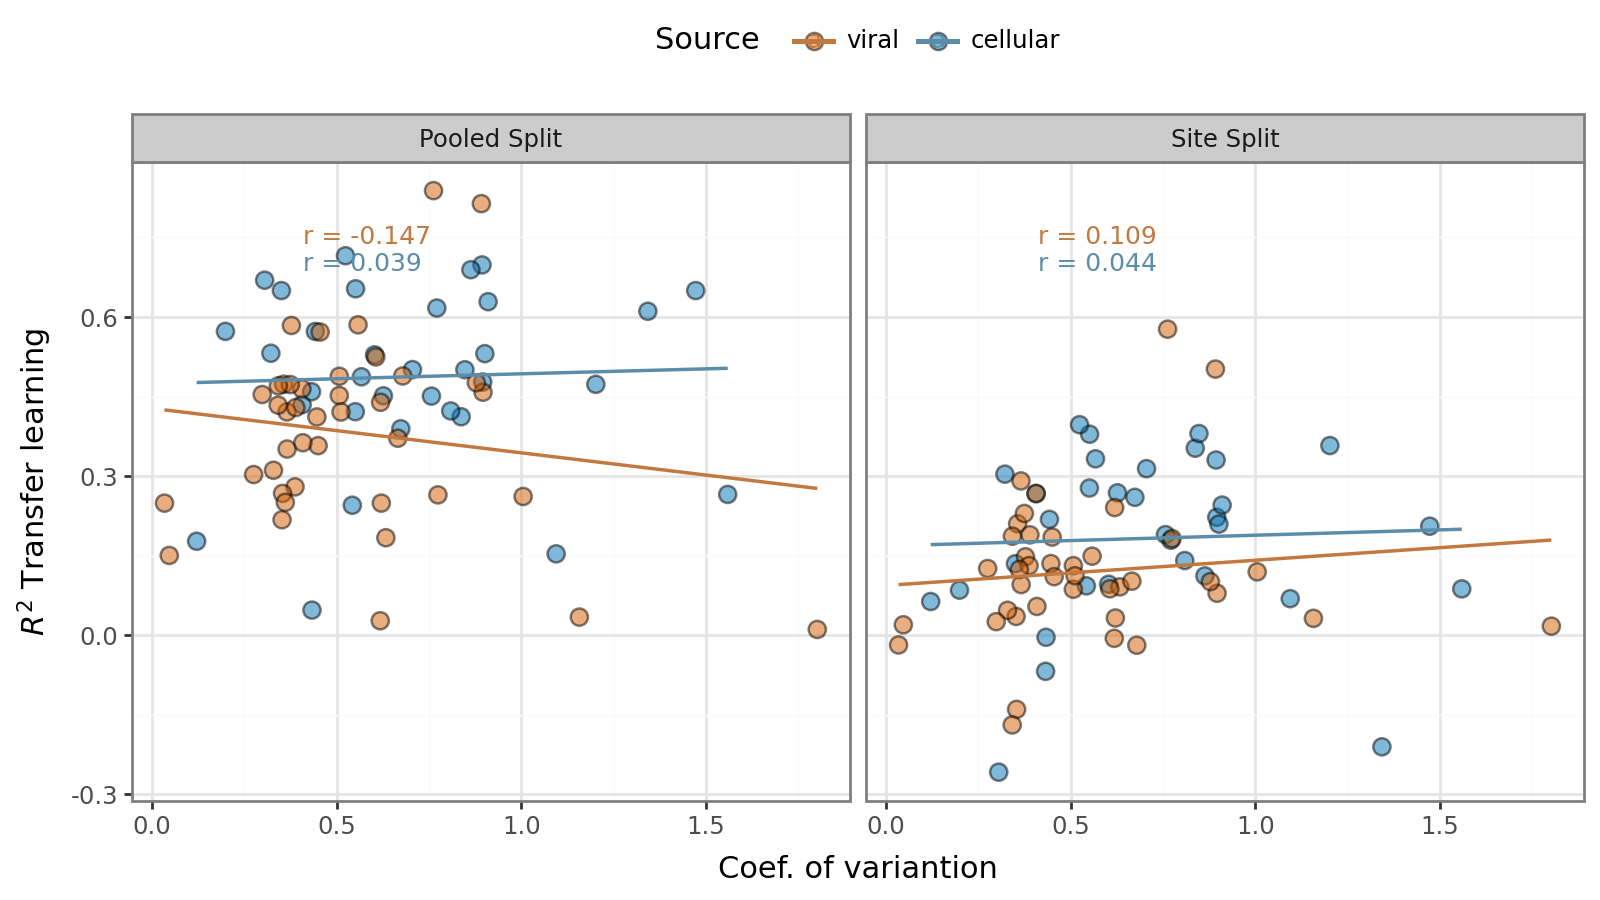

In [47]:
target = 'cv'
ann_df = annotation_df(res, target,  y=0.7)

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
         y='$R^2$ Transfer learning',
        x= 'Coef. of variantion')
    )

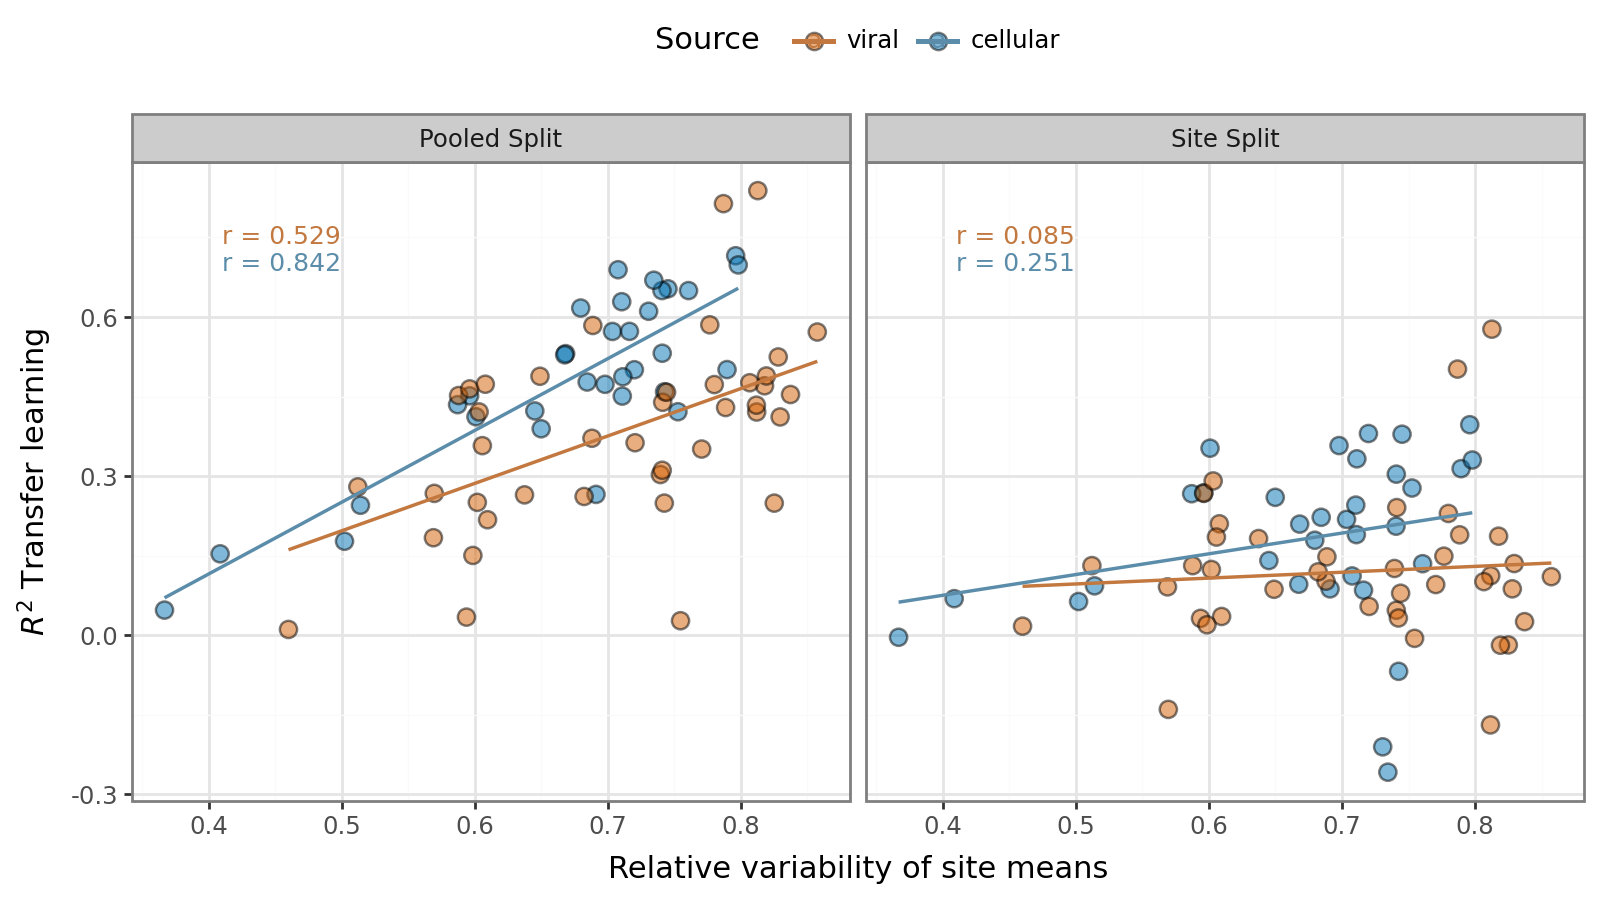

In [43]:
target = 'RVSM'
ann_df = annotation_df(res, target,  y=0.7)

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
         y='$R^2$ Transfer learning',
        x= 'Relative variability of site means')
    )
   

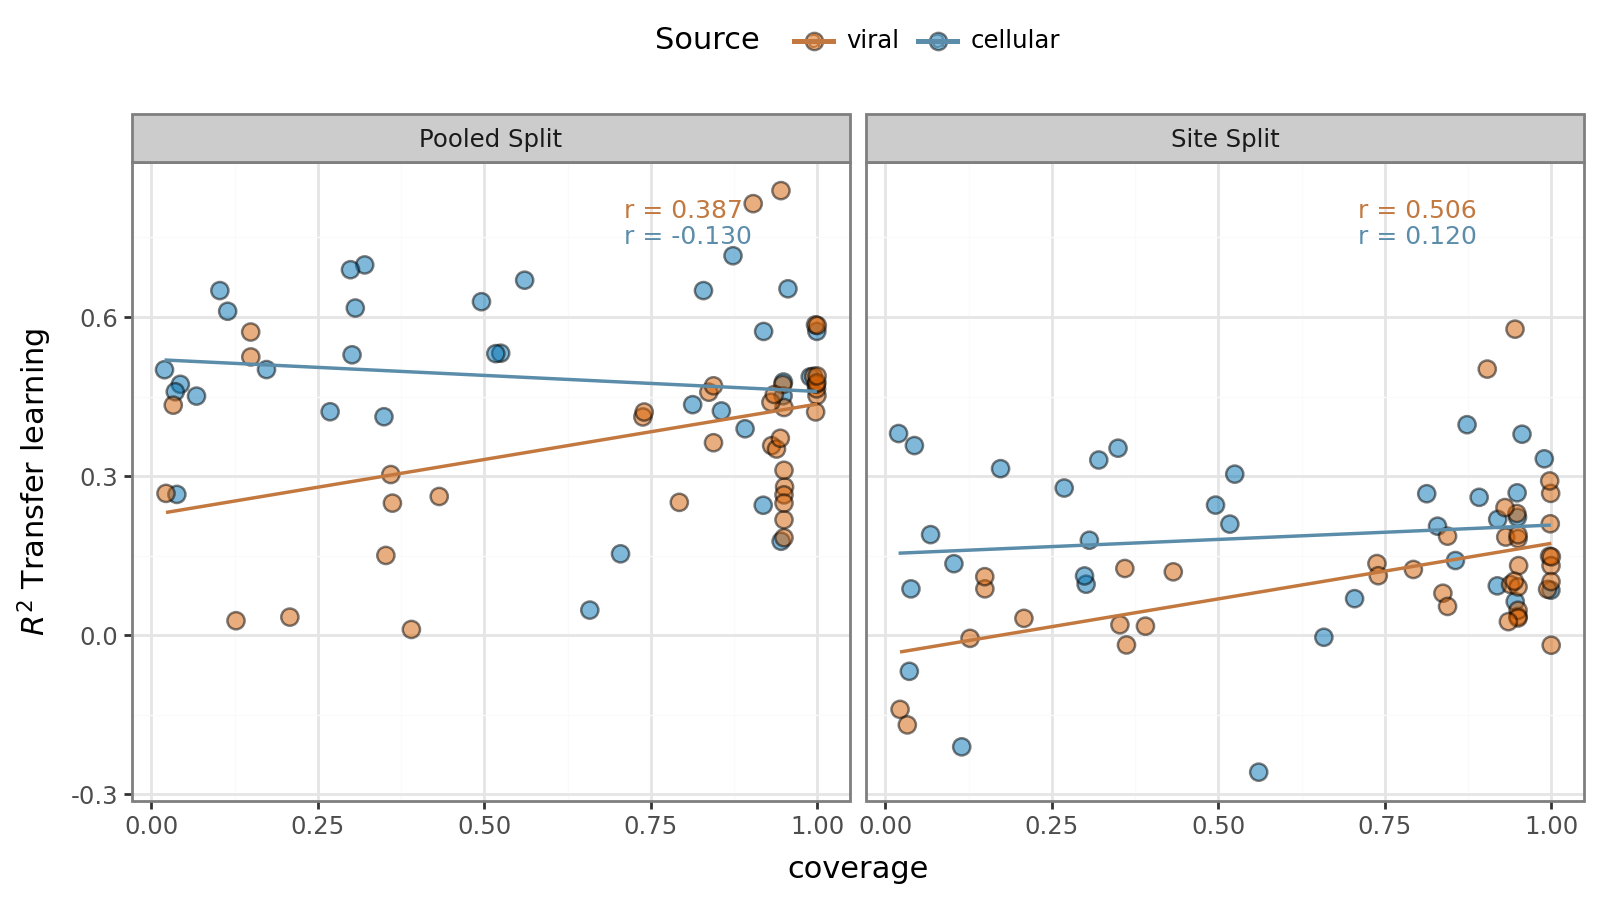

In [44]:
target = 'coverage'
ann_df = annotation_df(res, target, x=0.71, y=0.75)

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})

    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(y= '$R^2$ Transfer learning')
    )

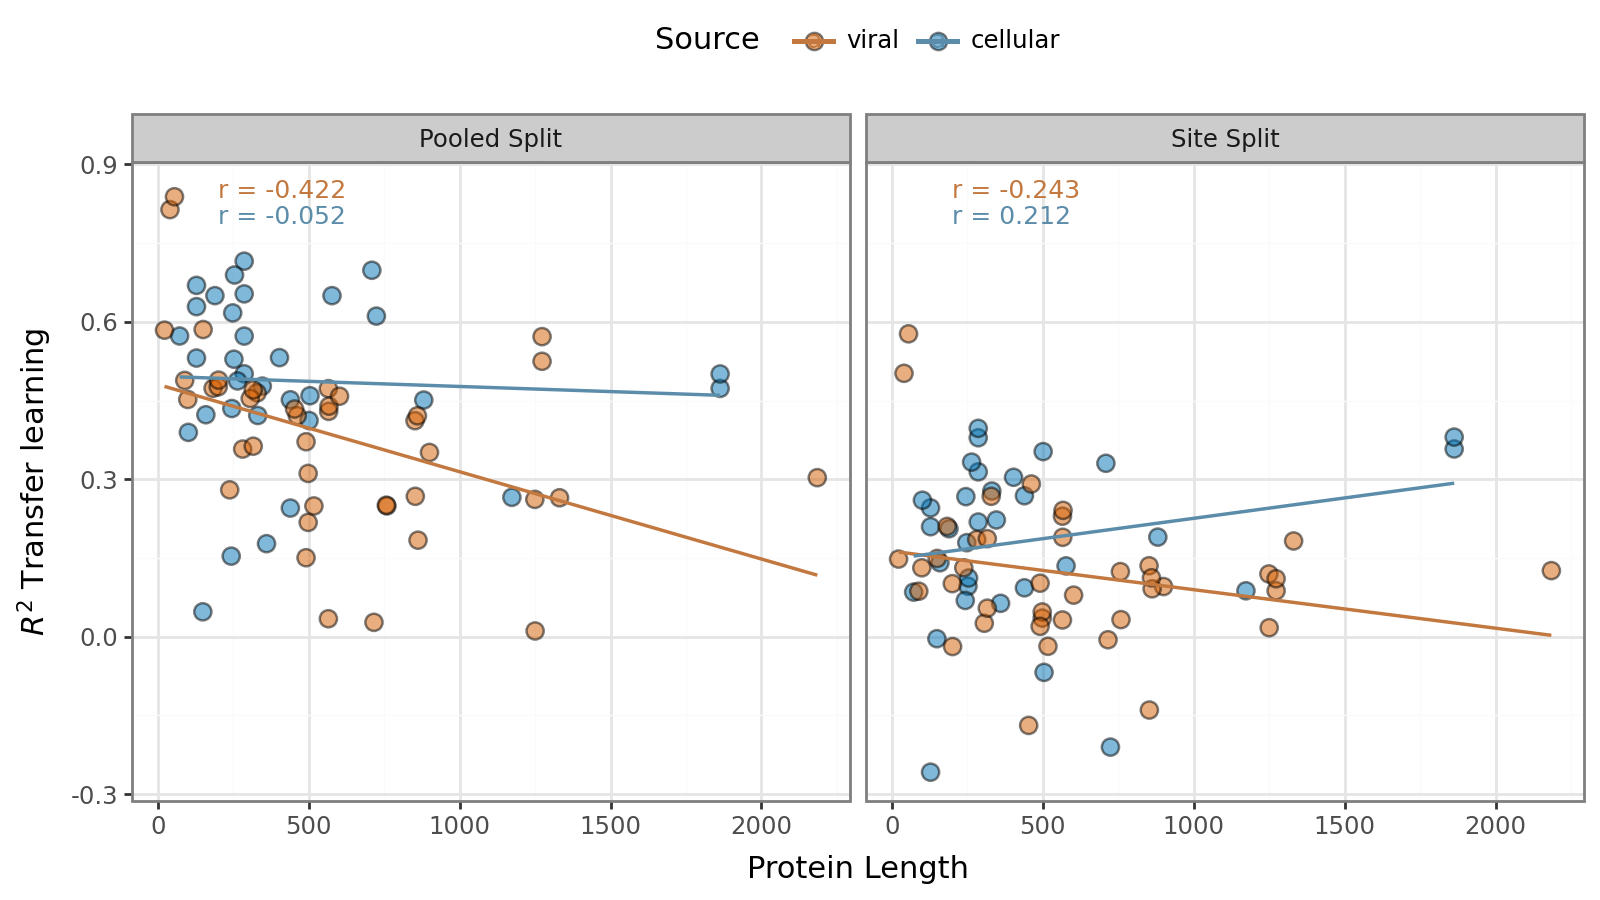

In [45]:
target = 'prot_length'
ann_df = annotation_df(res, target, x=200, y=0.8)

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Protein Length')
    )

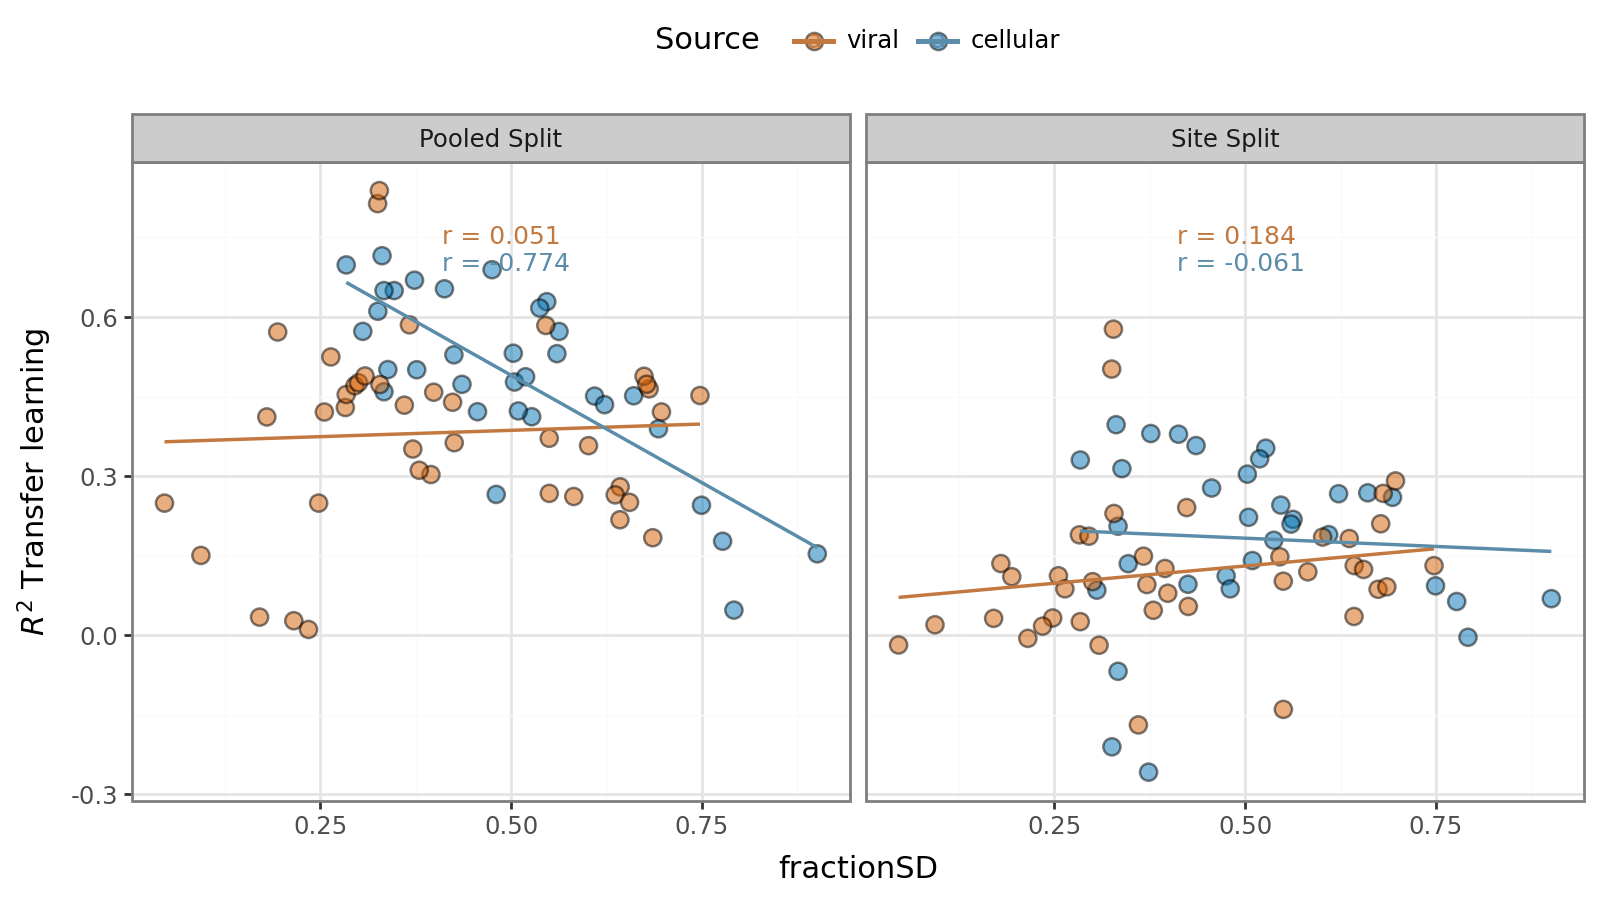

In [46]:
target = 'fractionSD'
ann_df = annotation_df(res, target,  y=0.7)

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'fractionSD')
    )

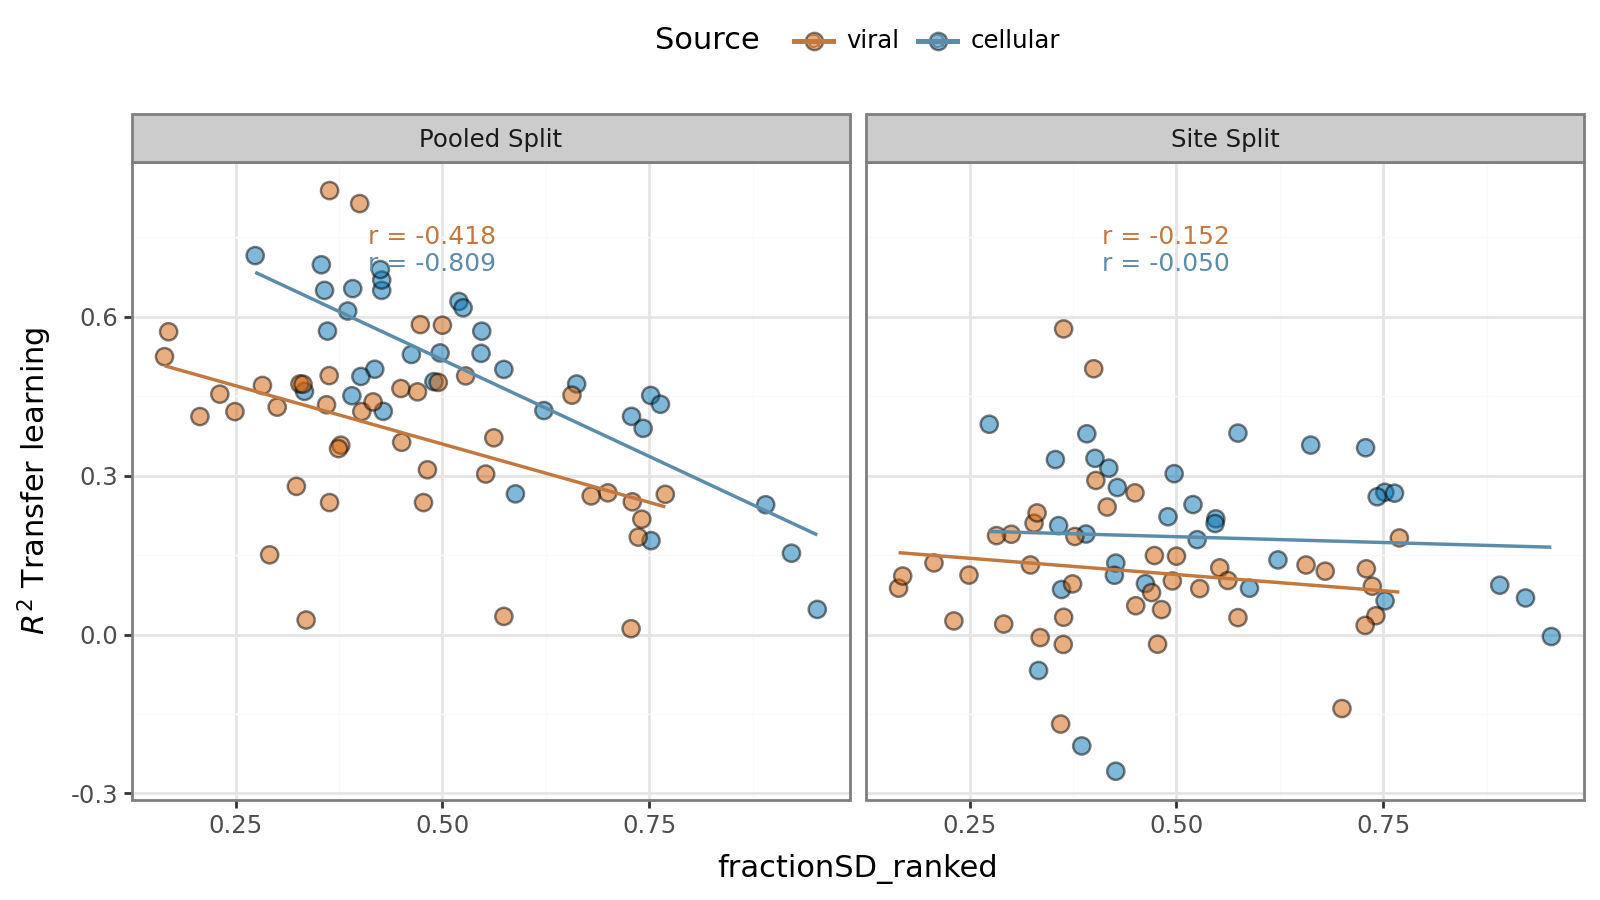

In [48]:
target = 'fractionSD_ranked'
ann_df = annotation_df(res, target,  y=0.7)

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
        y='$R^2$ Transfer learning')
    )

# OLS

In [36]:
res.columns

Index(['Model', 'Source', 'Split', 'Dataset', 'R2_score_test', 'cv', 'RVSM',
       'coverage', 'prot_length', 'fractionSD', 'fractionSD_ranked'],
      dtype='object')

In [19]:
model = ols('R2_score_test ~Source+RVSM+fractionSD+coverage+prot_length', data=res.query('Split in @p')).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     23.15
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           1.70e-13
Time:                        12:12:09   Log-Likelihood:                 60.033
No. Observations:                  74   AIC:                            -108.1
Df Residuals:                      68   BIC:                            -94.24
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.6629      0.169     

In [9]:
model = ols('R2_score_test ~Source+RVSM+fractionSD', data=res.query('Split in @p')).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     30.23
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           1.20e-12
Time:                        12:10:08   Log-Likelihood:                 54.002
No. Observations:                  74   AIC:                            -100.0
Df Residuals:                      70   BIC:                            -90.79
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.7819      0.177     

In [ ]:
model = ols('R2_score_test ~Source+RVSM+coverage+prot_length+fractionSD', data=res.query('Split in @p')).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     19.50
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           7.13e-14
Time:                        10:10:07   Log-Likelihood:                 64.729
No. Observations:                  74   AIC:                            -113.5
Df Residuals:                      66   BIC:                            -95.03
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.6003      0

In [39]:
model = ols('R2_score_test ~Source+cv+RVSM+coverage+prot_length+fractionSD+fractionSD_ranked', data=res.query('Split in @s')).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     3.453
Date:                Tue, 11 Nov 2025   Prob (F-statistic):            0.00329
Time:                        10:10:19   Log-Likelihood:                 47.949
No. Observations:                  74   AIC:                            -79.90
Df Residuals:                      66   BIC:                            -61.47
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.4650      0

In [40]:
model = ols('R2_score_test ~coverage+RVSM+Source', data=res).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     11.10
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           1.34e-06
Time:                        10:10:28   Log-Likelihood:                 32.662
No. Observations:                 148   AIC:                            -57.32
Df Residuals:                     144   BIC:                            -45.34
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.3915      0

In [41]:
model = ols('R2_score_test ~ RVSM', data=res.query('Source =="viral"')).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     5.538
Date:                Tue, 11 Nov 2025   Prob (F-statistic):             0.0211
Time:                        10:10:36   Log-Likelihood:                 16.962
No. Observations:                  82   AIC:                            -29.92
Df Residuals:                      80   BIC:                            -25.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1041      0.152     -0.683      0.4